In [1]:
import os
import sys
from pathlib import Path

# FOR LOCAL USE THIS LINES
current = Path.cwd()
src_path = current / "src" if (current / "src").exists() else current.parent

# FOR COLAB USE THIS LINE INSTEAD
# BRANCH_NAME = "weighted_loss"  # Change this to switch branches
# # !git clone -b {BRANCH_NAME} https://github.com/MatteoCamillo-code/GeoLoc-CVCS.git
# # !cd /content/GeoLoc-CVCS && git pull origin {BRANCH_NAME} && cd ..
# src_path = Path("/content/GeoLoc-CVCS/src").resolve()

sys.path.insert(0, str(src_path))

from utils.paths import find_project_root

# Set working directory and sys.path properly
project_root = find_project_root(src_path)
data_dir = project_root / "data"
history_dir = project_root / "outputs" / "history"
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print("CWD:", Path.cwd())

CWD: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS


In [2]:
from pathlib import Path
import pandas as pd

from pipelines import PipelineConfig, GeoLocPipeline

config = PipelineConfig(
    checkpoint_name="MH_res_cbam_wd_sp_mp16_v1",
    backbone="resnet50",
    use_cbam=True,
    image_root=data_dir / "classify" / "images",
    ground_truth_csv=data_dir / "classify" / "test_mini.csv",
    classify_batch_size=32,
    inference_batch_size=32,
    top_k=5,
)

pipeline = GeoLocPipeline(project_root=project_root, data_dir=data_dir, config=config)
print(f"Using device: {pipeline.device}")

classified_images = pipeline.classify_images()
print(f"\nClassification complete:")
print(f"  Urban: {len(classified_images['urban'])} images")
print(f"  Natural: {len(classified_images['natural'])} images")

c:\Users\camil\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Device: cuda
Loading scene hierarchy...
Loading resnet50...
Using device: cuda


Classifying batches: 100%|██████████| 22/22 [00:03<00:00,  6.71it/s]


Classification complete:
  Urban: 15 images
  Natural: 679 images


In [3]:
# Load models and predict GPS
model_bundle = pipeline.load_models()
results_df = pipeline.predict_gps(classified_images, model_bundle)

print("\nPredictions summary:")
print(results_df.head())

Predicting GPS (total): 100%|██████████| 22/22 [00:12<00:00,  1.79it/s]


Predictions summary:
             image_name scene_type  scene_confidence  predicted_lat  \
0  1203923296738984.jpg      total          0.762345      45.843102   
1   145232654232366.jpg      total          0.506096      37.742596   
2   150787090285906.jpg      total          0.790855      38.312748   
3   169487858298748.jpg      total          0.989652      43.223057   
4   215798546665447.jpg      total          0.524205      46.098042   

   predicted_lon  
0    -115.884834  
1     -99.303391  
2    -108.672798  
3    -116.604561  
4    -113.177147  


In [4]:
# Evaluate predictions (optional, if ground truth available)
eval_result = pipeline.evaluate(results_df)

if eval_result is not None:
    print("\nGPS Prediction Accuracy:")
    for metric, value in eval_result.accuracy.items():
        print(f"  {metric}: {value}")

    print("\nDistance Statistics:")
    print(f"  Mean distance: {eval_result.mean_km:.2f} km")
    print(f"  Median distance: {eval_result.median_km:.2f} km")
    print(f"  Min distance: {eval_result.min_km:.2f} km")
    print(f"  Max distance: {eval_result.max_km:.2f} km")

# Save results
output_path = project_root / "outputs" / "gps_predictions.csv"
results_df.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")


Results saved to: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\outputs\gps_predictions.csv


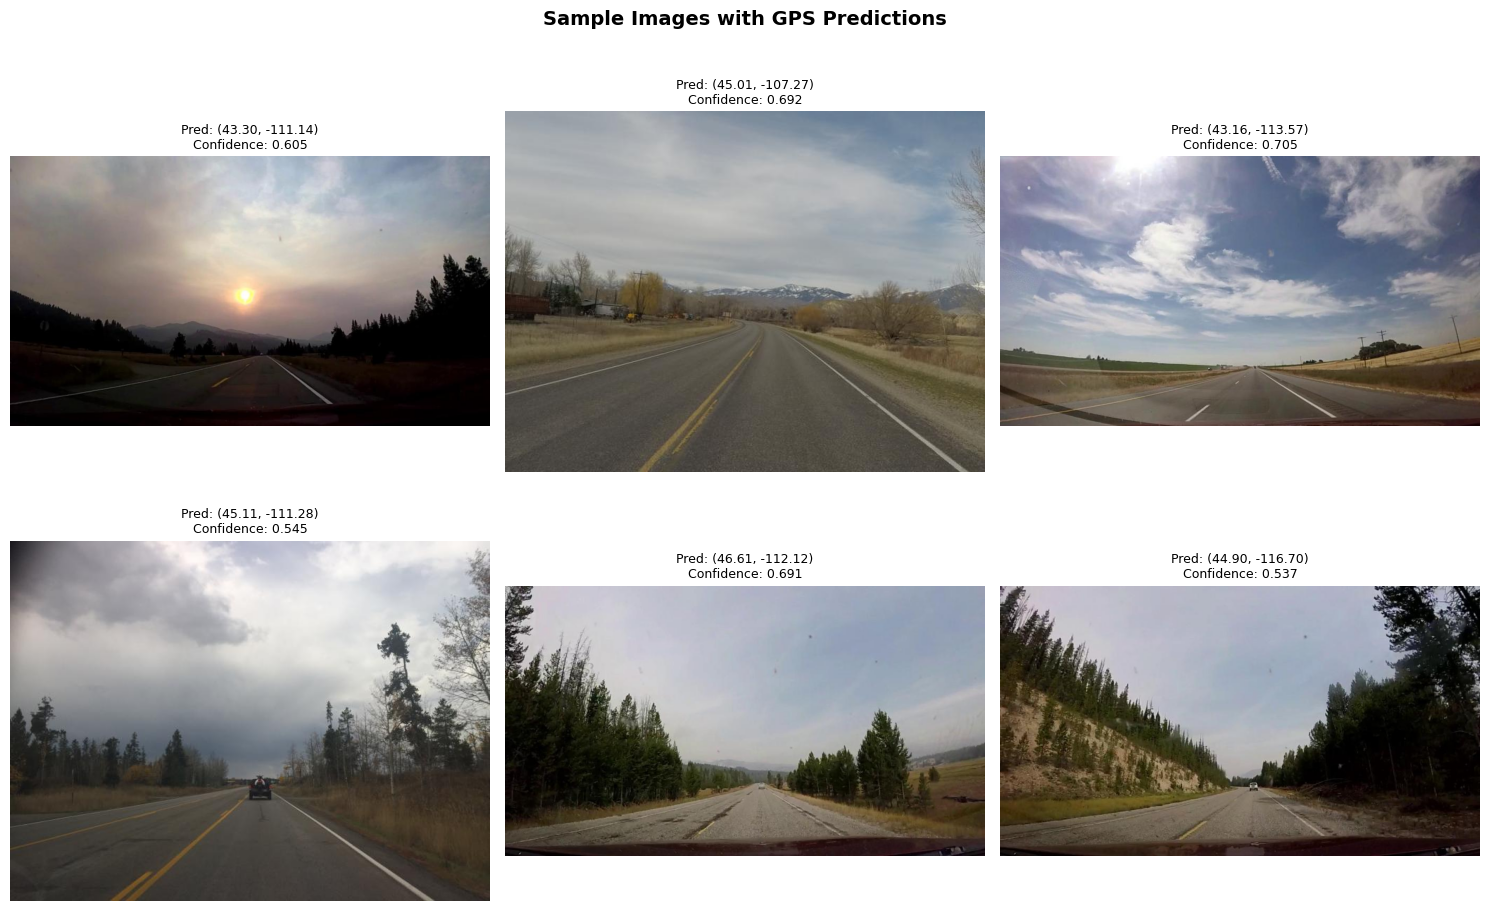


Pipeline complete!


In [7]:
# Visualize predictions
from pipelines.visualization import show_sample_images

show_sample_images(results_df, image_root=data_dir / "classify" / "images")

print("\nPipeline complete!")

In [8]:
# (Optional) More detailed evaluation
# You can inspect eval_result.merged for per-image distances when ground truth is available.
if eval_result is not None:
    display(eval_result.merged.head())